# TON-IOT Model Inference & Performance Testing

This notebook:
1. Loads a **saved preprocessing pipeline** and **trained model**
2. Uses the **same dataset split** (test set only)
3. Measures **inference performance** with resource monitoring

 **Important:** This notebook uses the **TEST SET** which was held out during training.

## 1. Setup & Imports

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from ton_iot_utils import print_system_info, save_inference_results
from ton_iot_pipeline import load_and_split_data, evaluate_model

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. System Information

Display hardware specs for this inference run

In [31]:
print_system_info()


Operating System:
  Platform: Windows 11
  Version:  10.0.26200
  Machine:  AMD64
  Processor: AMD64 Family 26 Model 68 Stepping 0, AuthenticAMD

CPU:
  Physical cores: 8
  Logical cores:  16
  CPU frequency:  4700.00 MHz

Memory:
  Total RAM: 61.6 GB
  Available RAM: 49.2 GB

Python:
  Version: 3.13.7


## 3. Configuration

In [32]:
# Configuration
CONFIG = {
    'dataset_path': 'data/train_test_network.csv',
    'pipeline_file': 'pipeline/shared_preprocessing_20260116_185312.pkl',
    'model_file': 'model/linearsvc_model_20260116_185312.pkl',
    'enable_monitoring': True,
    'random_state': 42  # Must match training notebook!
}

print("Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

print("\n  Important: random_state must match training notebook to ensure same test set!")

Configuration:
  dataset_path: data/train_test_network.csv
  pipeline_file: pipeline/shared_preprocessing_20260116_185312.pkl
  model_file: model/linearsvc_model_20260116_185312.pkl
  enable_monitoring: True
  random_state: 42

  Important: random_state must match training notebook to ensure same test set!


## 4. Load Dataset & Extract Test Set

Use the **same split** as training (same random_state)

In [33]:
print("="*70)
print("LOADING TEST SET")
print("="*70)

# Load and split (same as training)
X_train, X_val, X_test, y_train, y_val, y_test, _, _, _ = load_and_split_data(
    filepath=CONFIG['dataset_path'],
    random_state=CONFIG['random_state']  # Same random state = same split
)

LOADING TEST SET
Loading dataset...
Dataset shape: (211043, 44)
Features: ['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice', 'label', 'type']

Data split (stratified by attack type):
  Train: 147,730 samples (70.0%)
  Val:   31,656 samples (15.0%)
  Test:  31,657 samples (15.0%)

Label distribution (0=normal, 1=attack):
  Train: 76.31% attacks
  Val:   76.31% attacks
  Test:  76.31% attacks


## 5. Load Saved Pipeline & Model

In [34]:
print("="*70)
print("LOADING SAVED MODELS")
print("="*70)

print(f"\nLoading preprocessing pipeline: {CONFIG['pipeline_file']}")
preprocessing_pipeline = joblib.load(CONFIG['pipeline_file'])
print(" Pipeline loaded")

print(f"\nLoading trained model: {CONFIG['model_file']}")
model = joblib.load(CONFIG['model_file'])
print(" Model loaded")

print(f"\nModel information:")
print(f"  Type: {type(model).__name__}")
print(f"  Parameters: {model.get_params()}")

LOADING SAVED MODELS

Loading preprocessing pipeline: pipeline/shared_preprocessing_20260116_185312.pkl
 Pipeline loaded

Loading trained model: model/linearsvc_model_20260116_185312.pkl
 Model loaded

Model information:
  Type: LinearSVC
  Parameters: {'C': 0.002804138824696653, 'class_weight': 'balanced', 'dual': 'auto', 'fit_intercept': True, 'intercept_scaling': 1, 'loss': 'hinge', 'max_iter': 2000, 'multi_class': 'ovr', 'penalty': 'l2', 'random_state': 42, 'tol': 0.0001, 'verbose': 0}


## 6. Preprocess Test Set

In [35]:
print("="*70)
print("PREPROCESSING TEST SET")
print("="*70)

print(f"\nTransforming test set with saved pipeline...")
X_test_processed = preprocessing_pipeline.transform(X_test)

print(f"\n Preprocessing complete")
print(f"  Input shape:  {X_test.shape}")
print(f"  Output shape: {X_test_processed.shape}")

PREPROCESSING TEST SET

Transforming test set with saved pipeline...

 Preprocessing complete
  Input shape:  (31657, 42)
  Output shape: (31657, 79)


## 7. Evaluation with Resource Monitoring

Measure inference performance on test set


EVALUATION ON TEST SET
Resource monitoring started for: Test Inference
Resource monitoring stopped for: Test Inference

RESOURCE USAGE - Test Inference
Time:
  Wall time:     1.43 seconds
  Process time:  0.23 seconds (isolated CPU time)
  I/O wait:      1.20 seconds

Memory (Python objects):
  Peak:  0.83 MB
  Total increase:  0.35 MB

Memory (Total process):
  Peak:  355.05 MB
  Total increase:  1.10 MB

CPU:
  Average: 0.0%
  Peak:    0.0%
  Samples: 1

Energy:
  Consumption: 0.000109 kWh
  CO2 emissions: 0.000109 kg


Classification Report:
              precision    recall  f1-score   support

      Normal       0.95      0.83      0.89      7500
      Attack       0.95      0.99      0.97     24157

    accuracy                           0.95     31657
   macro avg       0.95      0.91      0.93     31657
weighted avg       0.95      0.95      0.95     31657


Confusion Matrix:
[[ 6257  1243]
 [  304 23853]]

  [[TN= 6257  FP= 1243]   TN: Normal correctly classified
   [FN=  304

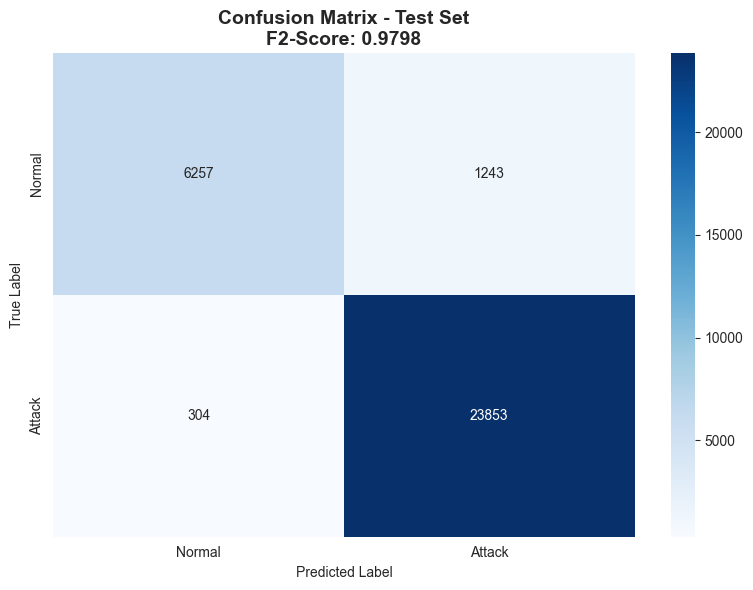

In [36]:
eval_results = evaluate_model(
    model=model,
    X_val=X_test_processed,
    y_val=y_test,
    monitor=CONFIG['enable_monitoring'],
    dataset_name="Test"
)

# Extract results for easier access
f1 = eval_results['f1']
f2 = eval_results['f2']
accuracy = eval_results['accuracy']
precision = eval_results['precision']
recall = eval_results['recall']
cm = eval_results['confusion_matrix']
inference_stats = eval_results['inference_stats']

# Visualize confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
ax.set_title(f'Confusion Matrix - Test Set\nF2-Score: {f2:.4f}', 
             fontsize=14, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 8. Save Results for Comparison

In [37]:
print("="*70)
print("SAVING RESULTS FOR MODEL COMPARISON")
print("="*70)

# Prepare metrics dictionary (direkt aus eval_results)
metrics_dict = {
    'accuracy': accuracy,
    'f1': f1,
    'f2': f2,
    'precision': precision,
    'recall': recall
}

# Extract model name from filename (e.g., 'svc_simple_model_20260107_162744.pkl' -> 'svc_simple')
model_name = CONFIG['model_file'].split('/')[-1].split('_model_')[0]

# Save results
result_file = save_inference_results(
    model_name=model_name,
    model_type=type(model).__name__,
    pipeline_file=CONFIG['pipeline_file'],
    model_file=CONFIG['model_file'],
    test_size=len(X_test_processed),
    metrics=metrics_dict,
    confusion_matrix=cm,
    inference_stats=inference_stats,
    output_dir='inference_results',
    config=CONFIG
)

print(f"\n Results saved to: {result_file}")
print(f"\nYou can now compare this model with others using:")
print(f"  - Load all JSON files from 'inference_results/' directory")
print(f"  - Use load_and_compare_results() to create comparison table")

SAVING RESULTS FOR MODEL COMPARISON

INFERENCE RESULTS SAVED
File: inference_results\linearsvc_inference_20260116_190019.json
Model: linearsvc (LinearSVC)
F2-Score: 0.9798
Detection Rate: 98.74%


 Results saved to: inference_results\linearsvc_inference_20260116_190019.json

You can now compare this model with others using:
  - Load all JSON files from 'inference_results/' directory
  - Use load_and_compare_results() to create comparison table
